# NYC Airbnb Data Inspection
I first checked data coverage, listing types, prices, stay rules, amenities, hosts, and locations before answering the seven assignment questions.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = next(
    (path for path in (Path.cwd(), Path.cwd().parent) if (path / "listings.csv").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")
sys.path.insert(0, str(ROOT / "scripts"))

from cleanup import FLAGS, clean

sns.set_theme(style="whitegrid", context="notebook")

raw = pd.read_csv(ROOT / "listings.csv", low_memory=False)
df = clean(raw)

df.shape

(30259, 54)

In [2]:
summary = pd.Series({
    "listings": len(df),
    "columns": df.shape[1],
    "unique listing IDs": df["id"].nunique(),
    "unique hosts": df["host_id"].nunique(),
    "priced listings": df["has_price"].sum(),
    "reviewed listings": df["has_reviews"].sum(),
    "long-stay-only listings": df["is_long_stay_only"].sum(),
})
summary.to_frame("count")

,count
listings,30259
columns,54
unique listing IDs,30259
unique hosts,16474
priced listings,21515
reviewed listings,21700
long-stay-only listings,24717


In [3]:
relevant_columns = [
    "borough",
    "neighborhood",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bathrooms_text",
    "bedrooms",
    "beds",
    "price_usd",
    "minimum_nights",
    "availability_30",
    "number_of_reviews",
    "review_scores_rating",
    "host_is_superhost",
]

missingness = (
    df[relevant_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
)

missingness.to_frame().round(1)

,missing_percent
bedrooms,36.3
bathrooms,33.4
beds,31.1
price_usd,28.9
review_scores_rating,28.3
host_is_superhost,1.2
bathrooms_text,0.5
minimum_nights,0.0
borough,0.0
neighborhood,0.0


In [4]:
price_coverage = pd.crosstab(
    df["source"],
    df["has_price"],
    margins=True,
)
price_coverage

has_price,False,True,All
source,,,
city scrape,1075,20386,21461
previous scrape,7669,1129,8798
All,8744,21515,30259


In [5]:
flag_counts = df[list(FLAGS)].sum().astype(int).sort_values(ascending=False)
flag_counts.to_frame("listings")

,listings
is_long_stay_only,24717
has_reviews,21700
has_review_score,21700
has_price,21515
is_multi_listing_host,16985
is_previous_scrape,8798
flag_quote_without_price,1163
flag_price_extreme,202
flag_geo_outside_nyc,0
flag_zero_accommodates,0


In [6]:
df.loc[df["has_price"], "price_usd"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    21515.000000
mean       278.229518
std        531.730477
min          4.580000
1%          39.470000
5%          52.730000
25%         96.875000
50%        174.690000
75%        302.720000
95%        759.000000
99%       1713.935000
max      30972.960000
Name: price_usd, dtype: float64

In [7]:
priced = df.loc[df["has_price"]].copy()

value_df = priced.loc[priced["accommodates"] > 0].copy()

print(f"All listings:       {len(df):,}")
print(f"Priced listings:    {len(priced):,}")
print(f"Price coverage:      {len(priced) / len(df):.1%}")
print(f"Value-analysis rows: {len(value_df):,}")

All listings:       30,259
Priced listings:    21,515
Price coverage:      71.1%
Value-analysis rows: 21,515


## Visual inspection
These plots show the main patterns and data limits I considered before answering the assignment questions.

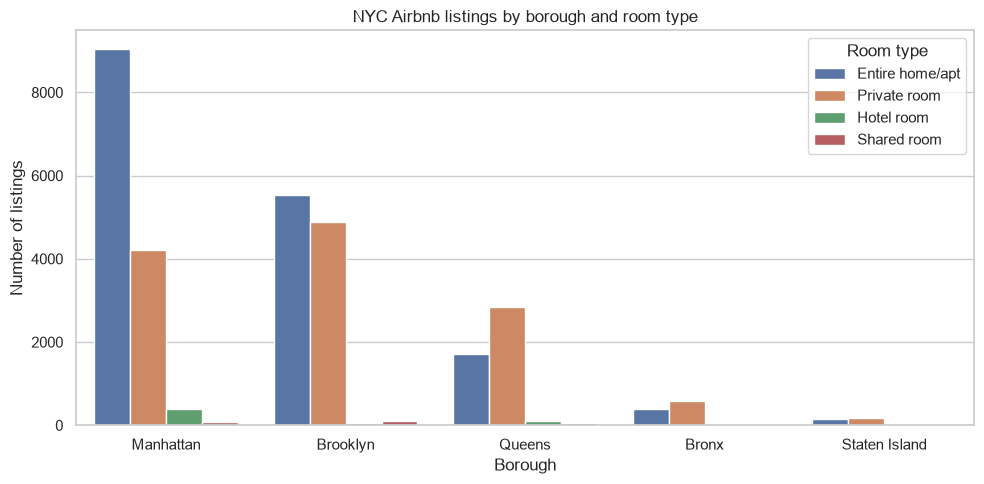

In [8]:
borough_order = df["borough"].value_counts().index
room_order = df["room_type"].value_counts().index

fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(
    data=df,
    x="borough",
    hue="room_type",
    order=borough_order,
    hue_order=room_order,
    ax=ax,
)

ax.set(
    title="NYC Airbnb listings by borough and room type",
    xlabel="Borough",
    ylabel="Number of listings",
)
ax.legend(title="Room type")
plt.tight_layout()

**What I noticed:** About 80% of the listings are in Manhattan or Brooklyn. Manhattan mostly has entire homes, while private rooms are more common in Queens and the Bronx, so I compare boroughs separately.

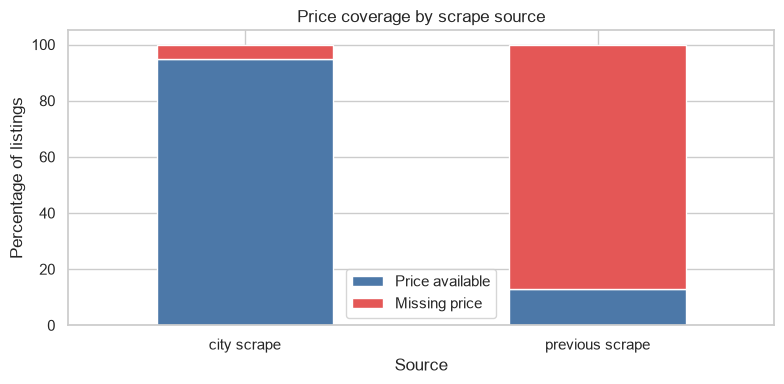

In [9]:
coverage_percent = (
    pd.crosstab(df["source"], df["has_price"], normalize="index")
    .mul(100)
    .rename(columns={False: "Missing price", True: "Price available"})
)

ax = coverage_percent[["Price available", "Missing price"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
    color=["#4c78a8", "#e45756"],
)

ax.set(
    title="Price coverage by scrape source",
    xlabel="Source",
    ylabel="Percentage of listings",
)
ax.legend(title="")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

**What I noticed:** Almost all current (`city scrape`) listings have a price, but most older (`previous scrape`) listings do not. Price availability mostly depends on the scrape source, so the missing prices do not appear random.

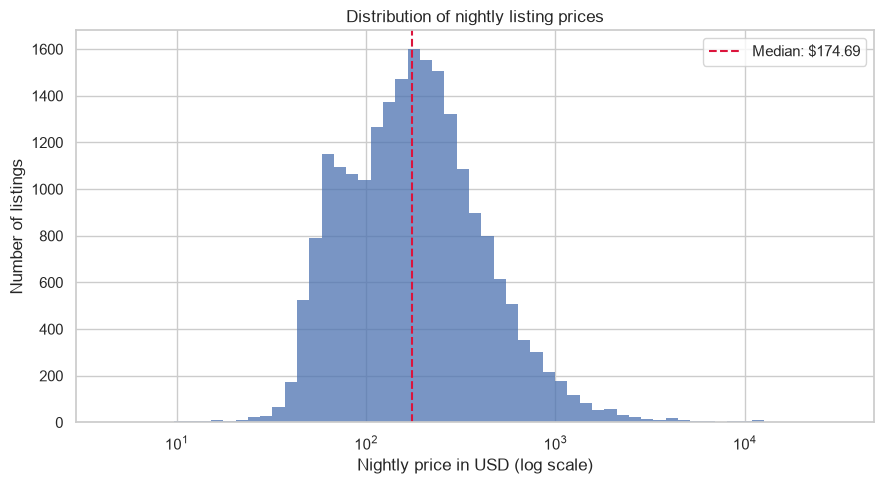

In [10]:
prices = priced["price_usd"]
bins = np.geomspace(prices.min(), prices.max(), 60)

fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(prices, bins=bins, ax=ax)
ax.axvline(
    prices.median(),
    color="crimson",
    linestyle="--",
    label=f"Median: ${prices.median():,.2f}",
)
ax.set_xscale("log")
ax.set(
    title="Distribution of nightly listing prices",
    xlabel="Nightly price in USD (log scale)",
    ylabel="Number of listings",
)
ax.legend()
plt.tight_layout()

**What I noticed:** A small number of very expensive listings pull the average up to $278, while the middle listing costs about $175. The median describes a typical listing better than the average here.

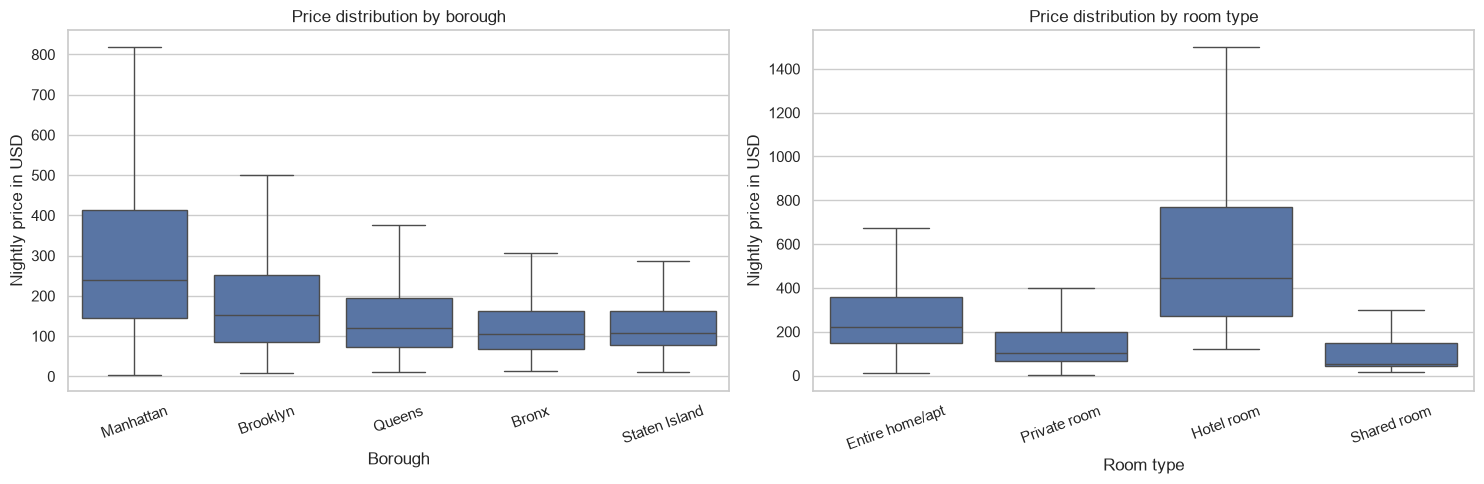

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=priced,
    x="borough",
    y="price_usd",
    order=borough_order,
    showfliers=False,
    ax=axes[0],
)
axes[0].set(
    title="Price distribution by borough",
    xlabel="Borough",
    ylabel="Nightly price in USD",
)
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=priced,
    x="room_type",
    y="price_usd",
    order=room_order,
    showfliers=False,
    ax=axes[1],
)
axes[1].set(
    title="Price distribution by room type",
    xlabel="Room type",
    ylabel="Nightly price in USD",
)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()

**What I noticed:** Manhattan is the most expensive borough, and hotel rooms and entire homes cost the most. Manhattan also has more entire homes, so the price gap reflects both location and room type.

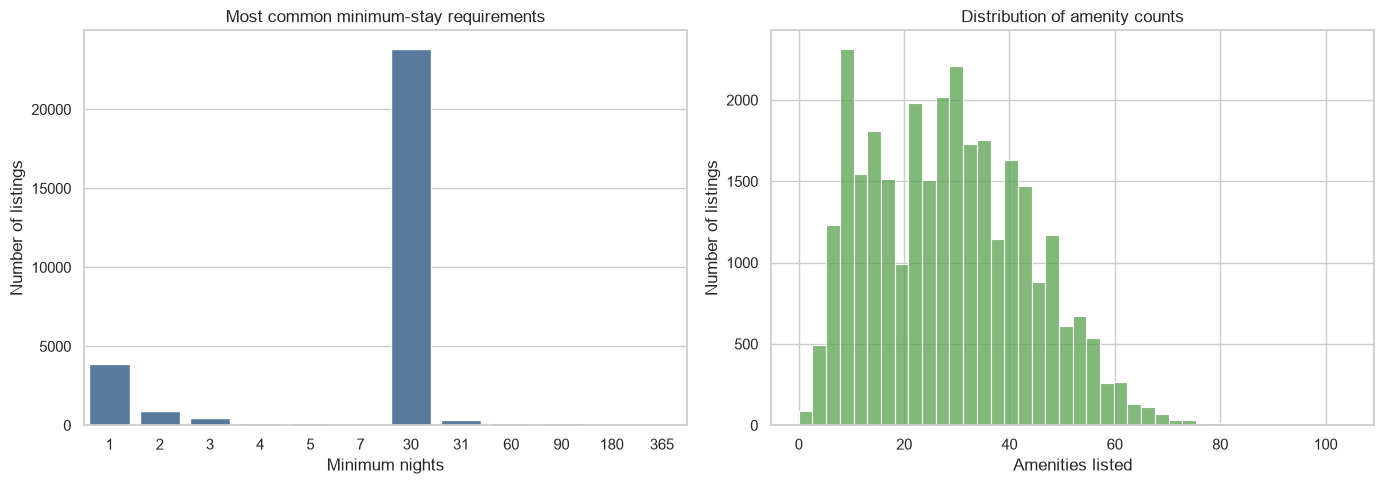

In [12]:
minimum_nights = df["minimum_nights"].dropna().astype(int)
common_minimums = minimum_nights.value_counts().nlargest(12).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=common_minimums.index.astype(str),
    y=common_minimums.values,
    color="#4c78a8",
    ax=axes[0],
)
axes[0].set(
    title="Most common minimum-stay requirements",
    xlabel="Minimum nights",
    ylabel="Number of listings",
)

sns.histplot(
    data=df,
    x="amenity_count",
    bins=40,
    color="#59a14f",
    ax=axes[1],
)
axes[1].set(
    title="Distribution of amenity counts",
    xlabel="Amenities listed",
    ylabel="Number of listings",
)

plt.tight_layout()

**What I noticed:** About 82% of listings require a stay of at least 30 nights, so I treat this as mainly a long-stay market. Amenity counts vary a lot, but a longer list does not necessarily mean better quality.

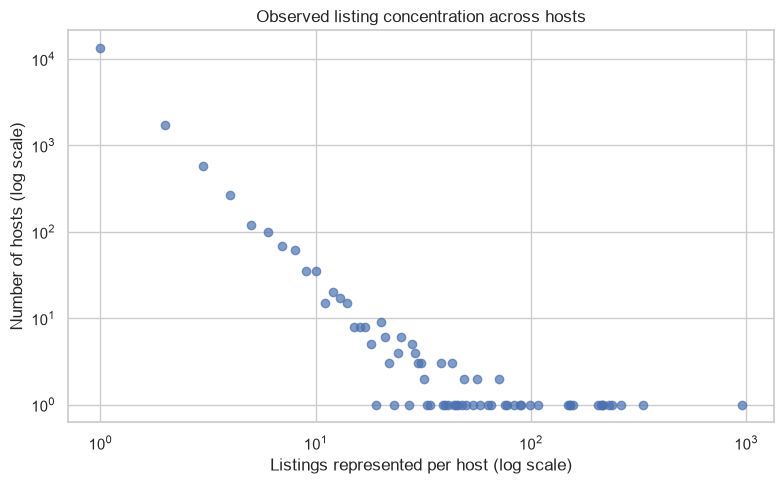

In [13]:
observed_host_size = df.groupby("host_id").size()
host_size_frequency = observed_host_size.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    host_size_frequency.index,
    host_size_frequency.values,
    alpha=0.7,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(
    title="Observed listing concentration across hosts",
    xlabel="Listings represented per host (log scale)",
    ylabel="Number of hosts (log scale)",
)
plt.tight_layout()

**What I noticed:** Most hosts have only one listing, but listings from multi-listing hosts make up more than half of the market. I check whether prices and amenities differ by host portfolio size in Part II.

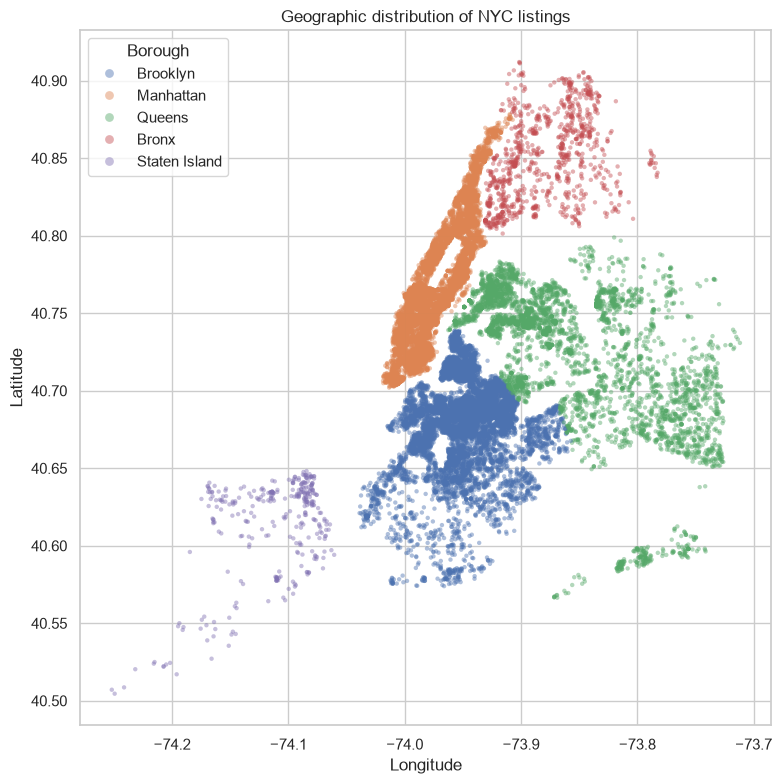

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="borough",
    s=10,
    alpha=0.45,
    linewidth=0,
    ax=ax,
)

ax.set(
    title="Geographic distribution of NYC listings",
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(title="Borough", markerscale=2)
plt.tight_layout()

**What I noticed:** The points form the expected shape of New York City, with no obvious locations far outside the city. I kept the coordinates for neighborhood comparisons.

## Notes I carried into Part II

- I use the 21,515 priced listings (71.1%) only when a question needs price.
- I prefer medians because a few unusually expensive listings pull averages upward.
- I compare similar room types and boroughs instead of relying only on city-wide prices.
- Because about 82% require at least 30 nights, I treat this as mainly a long-stay market.
- I treat amenities as host-reported and revenue and occupancy fields as estimates.
- I also check results by host because one host can appear in many listing rows.